# AB Aur: pipeline vs commissioning notebook

Reduces the same 92 frames as the commissioning notebook
(`working-ab-aur_07022026.ipynb`, 2025-12-07 L') **from raw** — darks, flats
and all — and compares the median Q_phi / U_phi against its saved reference.

It follows `examples/process_polmode.py` step for step, so the two line up:
sort, masters, reduce, geometry, cycles, fast axis + IP, Stokes. Only the last
step differs: a comparison instead of writing products.

Two bookkeeping differences from the notebook, both absorbed by fitting a
single scale factor: it omits the ½ factors in the double differences, and its
Q_phi uses the opposite sign convention. Our reduction also divides by ITIME
and COADDS and applies the gain, so the absolute units differ too — which is
exactly why the comparison fits a scale rather than assuming one.

## 0. Config

The reduction choices come from `ReductionConfig`, the same object
`process_polmode.py` loads from a TOML file — so the knobs mean exactly what
they mean there, and an incoherent pair is refused before any frame is read.
Built inline here rather than read from a file, because a comparison against a
fixed reference has no per-night settings to keep.

The handful of constants below it are specific to *this comparison* — where
the reference lives, how big a cutout to compare over — and are not reduction
choices, so they are not config fields.

In [1]:
import glob, logging, os, sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

from instruments import nirc2
from instruments.nirc2 import NIRC2PolarimetryData
from polarimetry import (build_stokes_cubes, fit_ip_uphi, fit_ip_uphi_all,
                         mean_ip, median_stokes_cube, radial_stokes)
from reduction.config import ReductionConfig
from reduction import (fit_beam_geometry, make_master_darks,
                       make_master_flats, make_master_masks, reduce_frame)
from utils import crop, frame_number, load_frames

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(message)s")
log = logging.getLogger("compare_ab_aur")

cfg = ReductionConfig(
    observations_root="/home/shared/exoserver/NIRC2_Pol/20251207",
    date="2025-12-07",
    target="AB_Aur",

    # the notebook's three science runs
    select_frame_range=[[857, 900], [915, 930], [932, 963]],

    background_method="mean_box",       # L' thermal background, per beam
    background_box=[25, 350, 50, 400],  # the notebook's box

    register_method="min",              # AB Aur's core is saturated

    fast_axis_method="fixed",           # compare at a pinned offset
    theta_off=-8.0278,                  # the notebook's own value

    ip_method=None,                     # the notebook applied none
    ip_mask_radius=22.0,
)

# --- specific to this comparison, not reduction choices -------------------
NOTEBOOK_DIR = os.path.expanduser("~/AB-Aur")

# Everything the reduction needs: the science runs, plus the sky flats that
# sit in the gap between them (902-913) and the matching darks (984-993).
RAW_RANGE = (857, 993)
CROP = 400

# Products land here, beside the notebook but out of the repo's history --
# examples/.gitignore keeps the folder untracked.
OUT_DIR = "compare_ab_aur_output"

for name, value in cfg.describe().items():
    print(f"  {name:22s} {value}")

  observations_root      /home/shared/exoserver/NIRC2_Pol/20251207
  date                   2025-12-07
  target                 AB_Aur
  select_target          None
  select_frame_range     [[857, 900], [915, 930], [932, 963]]
  background_method      mean_box
  background_box         [25, 350, 50, 400]
  background_annulus     None
  use_master_skies       False
  beam_top_row           None
  beam_x_offset          None
  register_method        min
  fast_axis_method       fixed
  theta_off              -8.0278
  fit_radii              [25.0, 150.0]
  ip_method              None
  ip_mask_radius         22.0


## 1. The instrument

One subclass carrying only the per-dataset choices — here just the
background — as `process_polmode.py` does with `NightPolData`.

In [2]:
class ABAurData(NIRC2PolarimetryData):
    """NIRC2-Pol as configured for this night, from the config."""

    background_method = cfg.background_method
    background_box = cfg.background_box


instrument = ABAurData()

## 2. Sort the raw frames

`sort_frames` classifies from the headers alone: shutter closed → dark,
`OBJECT` naming a sky or twilight flat → sky flat, telescope at the dome
position → dome flat, everything else → science.

In [3]:
lo, hi = RAW_RANGE
raw = [f for f in sorted(glob.glob(os.path.join(cfg.observations_root, "n*.fits")))
       if lo <= frame_number(f) <= hi]
sorted_files = instrument.sort_frames(raw)
for kind, files in sorted_files.items():
    print(f"{kind:14s} {len(files)}")

INFO Found 94 sci frames


INFO Found 0 flats_dome frames


INFO Found 13 flats_sky frames


INFO Found 30 darks frames


sci            94
flats_dome     0
flats_sky      13
darks          30


## 3. Master darks and flats

Frames are grouped by exposure settings, median-combined, sigma-clipped and
cleaned with the detector bad-pixel mask.

The sky flats here are a real test of the flat logic: `n0902`–`n0913` are
three complete HWP cycles, but `n0901` is a stray 67.5° frame before the
sequence proper. A polarimetric flat set has to cover every critical angle
**the same number of times** — the cycle average only cancels the flat
source's own polarization when the angles carry equal weight — so the extra
frame is set aside with a warning.

In [4]:
darks = load_frames(sorted_files["darks"])
master_darks, dark_masks = make_master_darks(darks, instrument=instrument)

master_flats, flat_masks = make_master_flats(
    load_frames(sorted_files["flats_dome"]),
    load_frames(sorted_files["flats_sky"]),
    master_darks, instrument=instrument)
master_masks = make_master_masks(dark_masks, flat_masks)

print(f"{len(master_darks)} master darks, {len(master_flats)} master flats")
for f in master_flats:
    print("  flat:", f["FILTER"], "| FLATTYPE", f["FLATTYPE"],
          "| polarimetric:", f.get("POLFLAT"), "| from", f["NFRAMES"], "frames")

INFO Making master for key -> (1024, 1024, 0.34, 1, 3, 4), count -> 10


INFO Making master for key -> (1024, 1024, 0.34, 30, 3, 4), count -> 10


INFO Making master for key -> (1024, 1024, 0.45, 45, 3, 4), count -> 10


WARNING Lp flats cover the cycle unevenly (0deg x3, 22.5deg x3, 45deg x3, 67.5deg x4), so 3 balanced cycle(s) are kept and 1 surplus frame(s) set aside: n0913.fits. These are sound frames -- they are dropped only because an angle observed more often than the others weights the cycle average toward it, and the flat source's own polarization stops cancelling.


INFO Found 12 polarimetric sky flats at critical angles (0 other sky flats)


INFO Making master for key -> (1024, 1024, 0.45, 45, 'Lp + Wollaston', 3, 4), count -> 12


INFO Subtracting dark from master flat (1024, 1024, 0.45, 45, 'Lp + Wollaston', 3, 4)


INFO Flat preference order: Lp + Wollaston/SKY/POL(n=12)


3 master darks, 1 master flats
  flat: Lp + Wollaston | FLATTYPE SKY | polarimetric: True | from 12 frames


## 4. Reduce the science frames

`(raw − dark) / flat`, then bad-pixel cleanup, then division by COADDS and
ITIME and multiplication by the gain. `select_frame_range` picks the notebook's
three runs out of the night's science frames.

In [5]:
def wanted(path):
    n = frame_number(path)
    return n is not None and any(a <= n <= b for a, b in cfg.select_frame_range)


sci_files = [f for f in sorted_files["sci"] if wanted(f)]
sci_frames = load_frames(sci_files)
bad_pixel_mask = instrument.bad_pixel_mask()
print(f"{len(sci_frames)} science frames")

frames = []
for f in sci_frames:
    frames.append(reduce_frame(
        f, master_flats, master_darks, None, master_masks,
        bad_pixel_mask=bad_pixel_mask,
        required_flat_types=instrument.required_flat_types,
        default_required_flat_type=instrument.default_required_flat_type,
        gain=instrument.gain(f),
        saturation_limit=instrument.saturation_limit(f)))

r = frames[0]
print(r["RED-FN"], "| dark subtracted:", r["DARKSUB"],
      "| flat divided:", r["FLATDIV"], "| units:", r.get("BUNIT"))

92 science frames


reduced_0857.fits | dark subtracted: True | flat divided: True | units: electron/s


## 5. Beam geometry

Measured from the data every time. The separation moves between epochs and
nothing downstream can undo a wrong value, so `split_beams` refuses until
this has run.

In [6]:
instrument.top_row_start, instrument.beam_x_offset = fit_beam_geometry(
    instrument, frames)
print("beam geometry:", instrument.top_row_start, instrument.beam_x_offset)

INFO beam geometry measured from 92 frame(s): top_row_start=505.05, beam_x_offset=12.63 (scatter 0.57, 0.08 px)


WARNING Measured beam_x_offset = 12.63 sits between pixels, so rounding either way leaves about half a pixel of beam misalignment. Compare both by reducing with each and seeing which gives less U_phi.


beam geometry: 505 13


## 6. HWP cycles

In [7]:
cycles = instrument.match_modulator_cycles(frames)
print(f"{len(cycles)} complete cycles")

INFO Matched 23 complete modulator cycles


23 complete cycles


## 7. Fast axis offset and instrumental polarization

The same two choices `process_polmode.py` makes. Both are pinned here, because
this is a comparison against a fixed reference: fitting the offset would
compare the pipeline against a moving target, and the notebook applied no
leakage correction. Change `ip_method` in the config cell to try a route.

In [8]:
theta_off = cfg.theta_off
ip = None

if cfg.ip_method == "fit_uphi_all":
    ip = fit_ip_uphi_all(instrument, cycles, theta_off,
                         mask_radius=cfg.ip_mask_radius, crop_size=CROP,
                         register_method=cfg.register_method)
elif cfg.ip_method == "fit_uphi_per_cycle":
    ip = [fit_ip_uphi(instrument, c, theta_off, mask_radius=cfg.ip_mask_radius,
                      crop_size=CROP, register_method=cfg.register_method)
          for c in cycles]
    print("mean:", mean_ip(ip).describe())
elif cfg.ip_method is not None:
    raise ValueError(f"this notebook handles None, fit_uphi_all and "
                     f"fit_uphi_per_cycle; got {cfg.ip_method!r}")

print(f"theta_off = {theta_off} deg, IP = {cfg.ip_method}")

theta_off = -8.0278 deg, IP = None


## 8. Stokes cubes

In [9]:
cubes = build_stokes_cubes(instrument, cycles, fast_axis_offset=theta_off,
                           register_method=cfg.register_method, ip=ip)
med = median_stokes_cube(cubes)
print("median cube:", med.shape)

median cube: (3, 450, 1011)


/home/blewis/NIRC2Pol-DPP/examples/../polarimetry/stokes.py:424: RuntimeWarning: All-NaN slice encountered
  return np.nanmedian(np.asarray(stokes_cubes), axis=0)


## 9. Crop, and find the star

`crop` quantises its origin, so the star does **not** land exactly on the
centre of the cutout — it is up to a pixel out. Carry that offset through and
tell `radial_stokes` where the star actually is: a pixel of error there leaks
disk signal straight into U_phi.

In [10]:
ny, nx = med[1].shape
star = ((ny - 1) / 2, (nx - 1) / 2)          # where registration puts it

I, sr, sc = crop(med[0], (CROP, CROP), center=star)
Q, _, _ = crop(med[1], (CROP, CROP), center=star)
U, _, _ = crop(med[2], (CROP, CROP), center=star)

star_in_crop = (star[0] - sr, star[1] - sc)
qphi, uphi = radial_stokes(Q, U, center=star_in_crop)
print(f"star sits at {star_in_crop} in the {CROP}x{CROP} crop")

star sits at (200.5, 200.0) in the 400x400 crop


## 10. Compare against the notebook

The notebook's star sits at (203, 197) in its own cutouts, so its images are
shifted onto ours before any pixelwise statistic. The scale factor is fitted,
absorbing the missing ½ factors, the sign convention and the units.

In [11]:
from utils.imutils import translate

nb_qphi = fits.getdata(os.path.join(NOTEBOOK_DIR, "qphi_median.fits"))
nb_uphi = fits.getdata(os.path.join(NOTEBOOK_DIR, "uphi_median.fits"))
nb_c = (203.0, 197.0)

dy, dx = star_in_crop[0] - nb_c[0], star_in_crop[1] - nb_c[1]
nb_qphi_al = translate(np.nan_to_num(nb_qphi), dy, dx)
nb_uphi_al = translate(np.nan_to_num(nb_uphi), dy, dx)

yy, xx = np.mgrid[:CROP, :CROP]
r = np.hypot(yy - star_in_crop[0], xx - star_in_crop[1])
ann = (r > 22) & (r < 150)

sel = ann & np.isfinite(qphi) & np.isfinite(nb_qphi_al) & (nb_qphi_al != 0)
a, b = qphi[sel], nb_qphi_al[sel]
scale = float(np.nansum(a * b) / np.nansum(a * a))
corr = float(np.corrcoef(a, b)[0, 1])

# U_phi has to be compared in the SAME units, so scale ours onto the
# notebook's before taking the ratio. Without that the number tracks whichever
# units the reduction happens to be in -- e.g. reducing from raw here gives
# electron/s and moves the fitted scale from ~2 to ~0.88, which would make an
# unscaled ratio look twice as bad for no physical reason.
uphi_ratio = np.nanstd(scale * uphi[sel]) / np.nanstd(nb_uphi_al[sel])

print(f"correlation      {corr:.4f}")
print(f"fitted scale     {scale:.4g}   (units + the missing 1/2 factors)")
print(f"residual std     {np.nanstd(b - scale * a) / np.nanstd(b):.3f}")
print(f"U_phi std ratio  {uphi_ratio:.3f}   (rescaled; <1 means ours is cleaner)")

correlation      0.9730
fitted scale     0.8838   (units + the missing 1/2 factors)
residual std     0.231
U_phi std ratio  0.989   (rescaled; <1 means ours is cleaner)


## 11. Save the products

Written to `examples/compare_ab_aur_output/`, which is untracked — these are
regenerated by running the notebook, so they do not belong in the history.

In [12]:
os.makedirs(OUT_DIR, exist_ok=True)

tag = f"theta{theta_off:g}_ip-{cfg.ip_method or 'none'}"
fits.PrimaryHDU(med).writeto(
    os.path.join(OUT_DIR, f"median_stokes_{tag}.fits"), overwrite=True)
fits.PrimaryHDU(np.stack([qphi, uphi])).writeto(
    os.path.join(OUT_DIR, f"qphi_uphi_{tag}.fits"), overwrite=True)

for name in sorted(os.listdir(OUT_DIR)):
    print(" ", name)

  comparison_theta-8.0278_ip-none.png
  median_stokes_theta-8.0278_ip-none.fits
  qphi_uphi_theta-8.0278_ip-none.fits


## 12. Look at it

U_phi is the null channel: if it is comparable to Q_phi there is no detection,
however good the image looks.

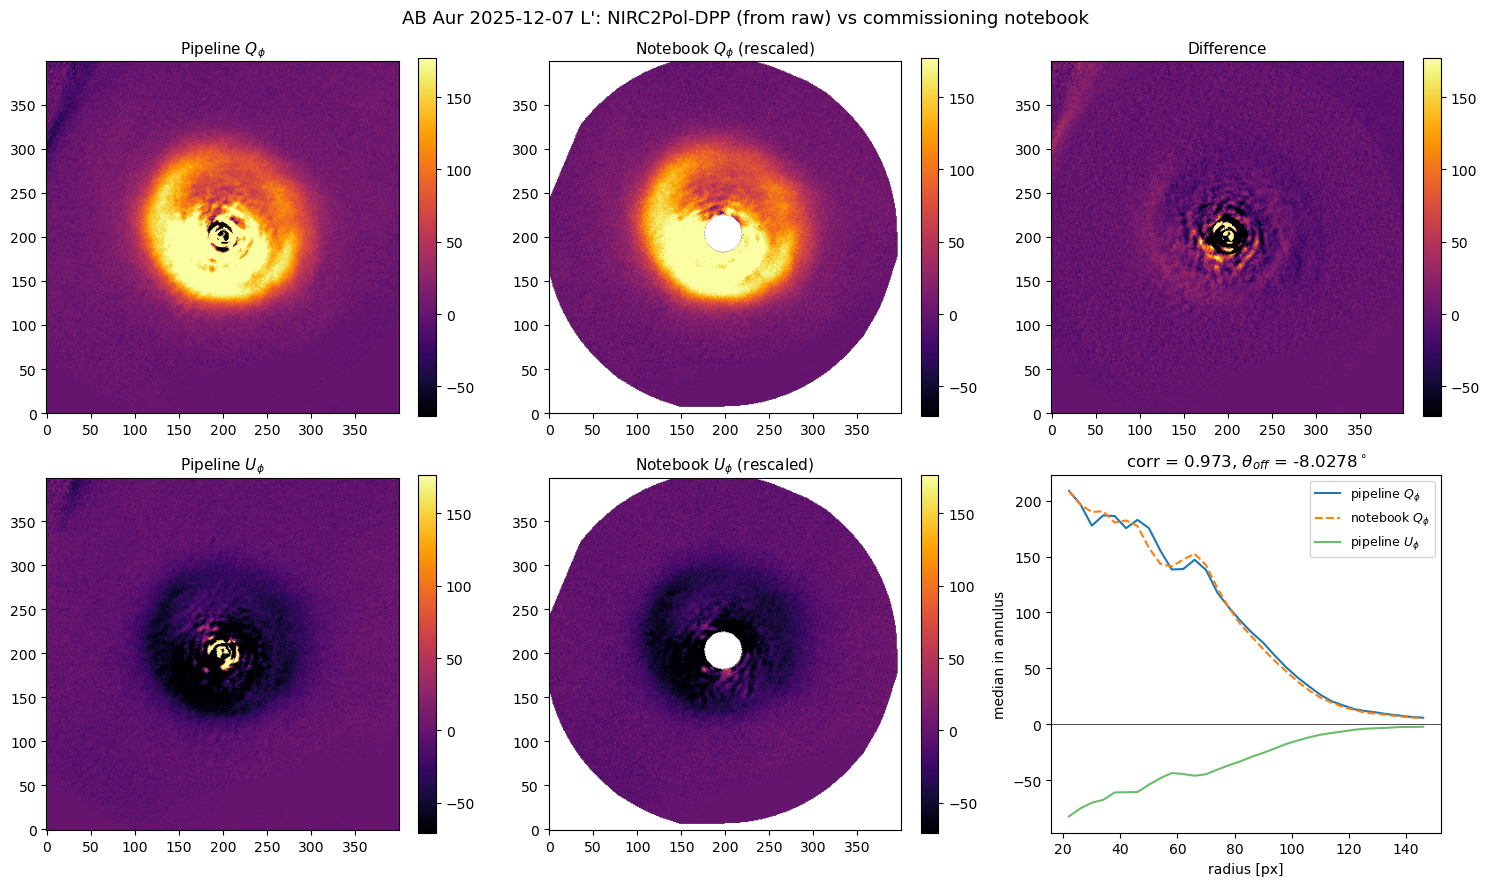

In [13]:
v = np.nanstd(b) / abs(scale)
nb_scaled = np.sign(scale) * nb_qphi / abs(scale)

fig, ax = plt.subplots(2, 3, figsize=(15, 9))
for a_, img, title in [
        (ax[0, 0], qphi, "Pipeline $Q_\\phi$"),
        (ax[0, 1], nb_scaled, "Notebook $Q_\\phi$ (rescaled)"),
        (ax[0, 2], np.sign(scale) * nb_qphi_al / abs(scale) - qphi, "Difference"),
        (ax[1, 0], uphi, "Pipeline $U_\\phi$"),
        (ax[1, 1], np.sign(scale) * nb_uphi / abs(scale),
         "Notebook $U_\\phi$ (rescaled)")]:
    im = a_.imshow(img, origin="lower", vmin=-v, vmax=2.5 * v, cmap="inferno")
    a_.set_title(title, fontsize=11)
    fig.colorbar(im, ax=a_, fraction=0.046)

bins = np.arange(22, 150, 4)
prof = lambda img: [np.nanmedian(img[(r >= b0) & (r < b0 + 4)]) for b0 in bins]
ax[1, 2].plot(bins, prof(qphi), label="pipeline $Q_\\phi$")
ax[1, 2].plot(bins, prof(np.sign(scale) * nb_qphi_al / abs(scale)), "--",
              label="notebook $Q_\\phi$")
ax[1, 2].plot(bins, prof(uphi), label="pipeline $U_\\phi$", alpha=0.7)
ax[1, 2].axhline(0, color="k", lw=0.5)
ax[1, 2].set_xlabel("radius [px]"); ax[1, 2].set_ylabel("median in annulus")
ax[1, 2].set_title(f"corr = {corr:.3f}, $\\theta_{{off}}$ = {theta_off}$^\\circ$")
ax[1, 2].legend(fontsize=9)

fig.suptitle("AB Aur 2025-12-07 L': NIRC2Pol-DPP (from raw) vs commissioning "
             "notebook", fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, f"comparison_{tag}.png"), dpi=110)